In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from IPython.display import display
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
from matplotlib.pyplot import figure
import pandas as pd
from scipy import integrate
import numpy.matlib
from scipy.optimize import curve_fit
from scipy.stats import norm
import statistics
from collections import deque
from operator import add
from scipy.integrate import odeint
from scipy.interpolate import RegularGridInterpolator

from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


from matplotlib.lines import Line2D
import time



##  Code to find the biophysical limit for f (gray area in Figure 5), courtesy of Stephen Beckett for code used in Beckett et. al 2024 (Disentangling top-down drivers of mortality underlying diel population dynamics of Prochlorococcus in the North Pacific Subtropical Gyre)

In [7]:
# functions to help evaluate properties of microbial communities
# inputs typically as microns, outputs typically at metres, seconds
#
# constants -- some constants.
# ViralQuota -- molar quotas of viruses from size
# GrazerQuota -- molar quotas of grazers from size
# dynamicViscosity -- computation of dynamic viscosity of seawater
# densitySW -- computation of seawater density
# kinematicViscosity -- computation of kinematic viscosity of seawater
# Stokes_Einstein_Sutherland -- translational diffusion
# Stokes_Einstein_Debye -- rotational diffusion
# SmoluchowskiCoagulation -- encounter via diffusion of spheres of differing radii.
# SwimmingSpeed -- microbial swimming speed as characterized by Kiørboe, 2011.
# RelativeSwimmingEncounter -- encounter via swimming of individuals of differing radii.
# Encounter -- encounter rates following equations from Talmy et al. 2019.

class Constants: 
    def __init__(constants): 
        constants.Avogadro = 6.02214076*10**23 #Avogadro's number [mol^(-1)]
        constants.Boltzmann = 1.380649*10**(-23) #Boltzmann constant [J/K = m^2.kg/(s^2.K)]
        constants.MM_C = 12.011 #molar mass carbon [g/mol]
        constants.MM_Fe = 55.845 #molar mass iron [g/mol]
        constants.MM_N = 14.007 #molar mass nitrogen [g/mol]
        constants.MM_O = 15.999 #molar mass oxygen [g/mol]
        constants.MM_P = 30.974 #molar mass phosphorous [g/mol]
        constants.MM_Si = 28.085 #molar mass silica [g/mol]

def Celcius2Kelvin(Temperature):
    return Temperature + 273.15

def ViralQuota(rv):
    #inputs: viral capsid radius rv in micron
    #outputs: quotas for C, N, P [mmol X per indiv] # milimole X per indiv
    rv = rv*1000 #convert from micron to nm
    #Following Jover et al. 2014 https://doi.org/10.1038/nrmicro3289
    x = (10**3/Constants().Avogadro)
    #Quotas from Jover et al. 2014: https://doi.org/10.1038/nrmicro3289
    # all in micromole X per virus
    QC = x*(41*(rv-2.5)**3 + 130*(7.5*rv**2 - 18.75*rv +15.63))
    QN = x*(16*(rv-2.5)**3 + 36*(7.5*rv**2 - 18.75*rv +15.63))
    QP = x*4.2*(rv-2.5)**3
    return QC, QN, QP


def radius_2_volume(radius):
    V = 4/3*math.pi*radius**3
    return V


def GrazerQuota(rg):
    #inputs: grazer radius rg in micron
    #output: quota for C, N [mmol X per indiv] #milimole X per indiv
    #Following dinoflagellate relationship in Menden-Deuer and Lessard, 2000. https://doi.org/10.4319/lo.2000.45.3.0569 (note may differ for other groups: e.g., https://doi.org/10.1002/lno.12284)
    mgC = 10**-9 * 0.76* radius_2_volume(rg)**0.819 #miligram C per cell
    mgN = 10**-9 * 0.118* radius_2_volume(rg)**0.849 #miligram N per cell
    QC = mgC/Constants().MM_C # milimolar C per cell
    QN = mgN/Constants().MM_N # milimolar N per cell
    return QC, QN
    

def dynamicViscosity(Temperature=23, Salinity=35):
    #inputs: Temperature as Celcius; Salinity as g/kg; defined for 0 < T < 180 C and 0 < S < 150 g/kg.
    #ouputs: dynamic viscocity of seawater [kg/m-s]
    
    # Following Sharqawy et al. 2010  https://doi.org/10.5004/dwt.2010.1079
    #from MIT seawater:  http://web.mit.edu/seawater/
    # VALIDITY: 0 < T < 180 C and 0 < S < 150 g/kg; ACCURACY: 1.5%
    
    S = Salinity
    T = Temperature
    S = S/1000
    a = np.array([1.5700386464E-01,6.4992620050E+01,-9.1296496657E+01,4.2844324477E-05,1.5409136040E+00,1.9981117208E-02,-9.5203865864E-05,7.9739318223E+00,-7.5614568881E-02,4.7237011074E-04])
    mu_w = a[3] + 1/(a[0]*(T+a[1])**2+a[2])
    A  = a[4] + a[5] * T + a[6] * T**2
    B  = a[7] + a[8] * T + a[9]* T**2
    mu = mu_w*(1 + A*S + B*S**2) # [kg/m-s]
    return mu


def densitySW(Temperature=23, Salinity=35, Pressure = 0.101325):
    #inputs: Temperature as Celcius; Salinity as g/kg; Pressure as MPa; defined for 0 < T < 180 C and 0 < S < 150 g/kg and 0 < P < 12 MPa.
    #output: denity of seawater [kg/m^3]
    #Following Nayar et al. 2016. http://dx.doi.org/10.1016/j.desal.2016.02.024
    #from MIT seawater:  http://web.mit.edu/seawater/
    T = Temperature
    S = Salinity/1000
    P = Pressure
    P0 = 0.101325 # atmospheric pressure [MPa]
    a = np.array([9.999*10**2, 2.034*10**-2, -6.162*10**-3, 2.261*10**-5, -4.657*10**-8])
    b = np.array([8.02*10**2, -2.001, 1.677*10**-2, -3.06*10**-5, -1.613*10**-5])
    psw_P0 = (a[0] + a[1]*T + a[2]*T**2 + a[3]*T**3 + a[4]*T**4) + (b[0]*S + b[1]*S*T + b[2]*S*T**2 + b[3]*S*T**3 + b[4]*S**2*T**2)
    cc = np.array([5.0792*10**-4, -3.4168*10**-6, 5.6931*10**-8, -3.7263*10**-10, 1.4465*10**-12, -1.7058*10**-15, -1.3389*10**-6, 4.8603*10**-9, -6.8039*10**-13])
    d = np.array([-1.1077*10**-6, 5.5585*10**-9, -4.2539*10**-11, 8.3702*10**-9])
    Fp = exp((P-P0)*(cc[0]+cc[1]*T+cc[2]*T**2+cc[3]*T**3+cc[4]*T**4+cc[5]*T**5 + S*(d[0]+d[1]*T+d[2]*T**2)) + 0.5*(P**2-P0**2)*(cc[6]+cc[7]*T+cc[8]*T**3+d[3]*S))
    rho = Fp*psw_P0
    return rho
	

def kinematicViscosity(Temperature=23, Salinity=35, Pressure = 0.101325):
    #inputs: Temperature as Celcius; Salinity as g/kg; Pressure as MPa; defined for 0 < T < 180 C and 0 < S < 150 g/kg and 0 < P < 12 MPa.
    #output: Kinematic viscosity [m^2/s]
    v = dynamicViscosity(Temperature, Salinity)
    rho = densitySW(Temperature, Salinity, Pressure)
    k = v/k
    return k


def Stokes_Einstein_Sutherland(radius, Temperature=23, Salinity=35): #translational diffusion - movement across space
    #inputs: radius as micron; Temperature as Celcius; Salinity as g/kg; defined for 0 < T < 180 C and 0 < S < 150 g/kg.
    #output: diffusion as [m^2/s]
    DynamicViscosity = dynamicViscosity(Temperature,Salinity) # [kg/m-s]
    Diff_t = (Constants().Boltzmann*Celcius2Kelvin(Temperature))/( 6*math.pi*micron_2_metre(radius)*DynamicViscosity ) # [m^2/s]
    return Diff_t


def Stokes_Einstein_Debye(radius, Temperature=23, Salinity=35): #rotational diffusion - angular rotation
    #inputs: radius as micron; Temperature as Celcius; Salinity as g/kg; defined for 0 < T < 180 C and 0 < S < 150 g/kg.
    #output: diffusion as [m^2/s]
    DynamicViscosity = dynamicViscosity(Temperature,Salinity) # [kg/m-s]
    Diff_r = (Constants().Boltzmann*Celcius2Kelvin(Temperature))/( 8*math.pi**micron_2_metre(radius)**3*DynamicViscosity ) # [m^2/s]
    return Diff_r


def SmoluchowskiCoagulation(radius1,radius2, Temperature=23, Salinity=35):
    #inputs:  radius1, radius2 in micron; Temperature as Celcius; Salinity as g/kg; defined for 0 < T < 180 C and 0 < S < 150 g/kg.
    #ouput: encounter rate via diffusion between spheres of radius1 and radius2 [m^3/s]
    SC = 4*math.pi*(micron_2_metre(radius1) + micron_2_metre(radius2))*(Stokes_Einstein_Sutherland(radius1,Temperature,Salinity) + Stokes_Einstein_Sutherland(radius2,Temperature,Salinity)) # [m^3/s]
    return SC
    

def SwimmingSpeed(radius):
    #inputs: radius as micron.  Valid for 1 micron to 1 cm.
    #output: swimming speed as  m per second
    
    #Following Talmy et al. 2019. Front. Mar. Sci. https://doi.org/10.3389/fmars.2019.00182; from Kiørboe, 2011. Biological Reviews. https://doi.org/10.1111/j.1469-185X.2010.00148.x
    u = math.exp(0.39 + 0.79*math.log((2*radius)/10**4))/10**2 # [m/s]
    return u


def micron_2_metre(x):
    return x/(10**6)


def RelativeSwimmingEncounter(radius1, radius2, fdetect=3, Temperature=23, Salinity=35):
    #inputs:  radius1, radius2 as micron; fdetect as scaler: detect = fdetect*r; Temperature as Celcius; Salinity as g/kg; defined for 0 < T < 180 C and 0 < S < 150 g/kg.
    #output:  encounter rate [m^3/second]
    
    #Following Talmy et al. 2019 https://doi.org/10.3389/fmars.2019.00182
    predator = micron_2_metre(max(radius1,radius2))
    prey = micron_2_metre(min(radius1,radius2))
    swim1 = SwimmingSpeed(radius1)
    swim2 = SwimmingSpeed(radius2)
    Enc = ((swim1**2+swim2**2)**0.5)*math.pi*(predator*fdetect + prey)**2  # m^3 per second
    return Enc


def EncounterRate(prey_radius, predator_radius, fdetect=3, Temperature=23, Salinity=35, Enc_Type=1):
    #inputs:  prey_radius, predator_radius as micron; fdetect as scaler: detect = fdetect*r; Temperature as Celcius; Salinity as g/kg; defined for 0 < T < 180 C and 0 < S < 150 g/kg.
    #Enc_Type -- 1), full predator-prey setup (assuming both motile) 2), predator-prey assuming both motile and predator diffusion is negligble, 3) predator-prey assuming diffusive predator, with mobile prey.
    #output:  encounter rate [m^3/second]
    #Following Talmy et al. 2019. https://doi.org/10.3389/fmars.2019.00182
    if Enc_Type==1:  #equation 4
        Encounter = RelativeSwimmingEncounter(prey_radius,predator_radius,fdetect,Temperature,Salinity) + SmoluchowskiCoagulation(prey_radius,predator_radius,Temperature,Salinity)
    elif Enc_Type==2: #equation 5 - motile predators (grazers)
        Encounter = RelativeSwimmingEncounter(prey_radius,predator_radius,fdetect,Temperature,Salinity) + 4*math.pi*(Stokes_Einstein_Sutherland(prey_radius,Temperature,Salinity))*(prey_radius+predator_radius)
    elif Enc_Type==3: # equation 6 - diffusion predators (viruses)
        Encounter = math.pi*SwimmingSpeed(prey_radius)*(prey_radius+predator_radius)**2 + SmoluchowskiCoagulation(prey_radius,predator_radius,Temperature,Salinity)
    elif Enc_Type==4: # diffusion only
        Encounter = SmoluchowskiCoagulation(prey_radius,predator_radius,Temperature,Salinity)
    elif Enc_Type==5: # swimming only
        Encounter = RelativeSwimmingEncounter(prey_radius,predator_radius,fdetect,Temperature,Salinity)
    else:
        warnings.warn("Input for Enc_Type is not documented")
    return Encounter

virus_radius = micron_2_metre(0.1/2)
f_val_enc = EncounterRate(virus_radius,virus_radius)

bio_phys_lim = f_val_enc*86400*1000 ##biophysical limit converted from m^3/second to L/day

# Fixed parameters and functions

In [9]:


omega = 0.257
lambda_I = 4.5
V_target = 5e8
n_fixed = 100.0
d_A = 1

r = 1.0
K = 7.76*10**8
beta = 24

q0 = 0.01
phi_ratios = [1.0, 5.0, 10.0, 20.0, 30.0]
q_values = [0.01, 0.025, 0.05, 0.075, 0.10]


f_limit = bio_phys_lim
f_plot_max = 3.0 * f_limit
f_min = 1e-13
panel_c_ymax = 3e-9

f_values = np.logspace(np.log10(f_min), np.log10(f_plot_max), 6000)
x_values = 1.0 + np.logspace(-5, np.log10(4.0), 5000)


# Panel a functions
# z(f) = V1*/Vtarget = 2 / [1 + sqrt(1 + 4nfVtarget/dA)] (Equation 52)
# y(f) = V2*/Vtarget = 1 - z(f) (Equation 53)


def z(f):
    return 2.0 / (1.0 + np.sqrt(1.0 + 4.0*n_fixed*f*V_target/d_A))

def y(f):
    return 1.0 - z(f)


# Panel b functions
# q(f,x) = 2xq0 / [(1-q0)(1 + sqrt(1 + 4nfVtarget/dA)) + 2xq0] (Equation 76)
# where x = phi_A / phi_NA (Equation 66)

def q_infected(f, x):
    return 2.0*x*q0 / ((1.0-q0)*(1.0 + np.sqrt(1.0 + 4.0*n_fixed*f*V_target/d_A)) + 2.0*x*q0)


# Panel c functions
# f = d_NA/(n Vtarget) * x^2 * (x - 1) (Equation 112)
# where x = phi_A / phi_NA

def d_NA(q):
    return K*(beta*lambda_I-lambda_I-omega)*q/(r*V_target) * (r-omega-(lambda_I+omega)*q/(1.0-q))

def f_nonidentifiability(x, q):
    return d_NA(q)/(n_fixed*V_target) * x**2 * (x-1.0)

phi_NA= (lambda_I + omega) * q0 / ((1.0 - q0) * V_target) 
#print(phi_NA_reference)

# Figure 5: Showing how aggregation can supress levels of infection, and that aggregation and adsoprtion are therefore coupled and non-identifiable

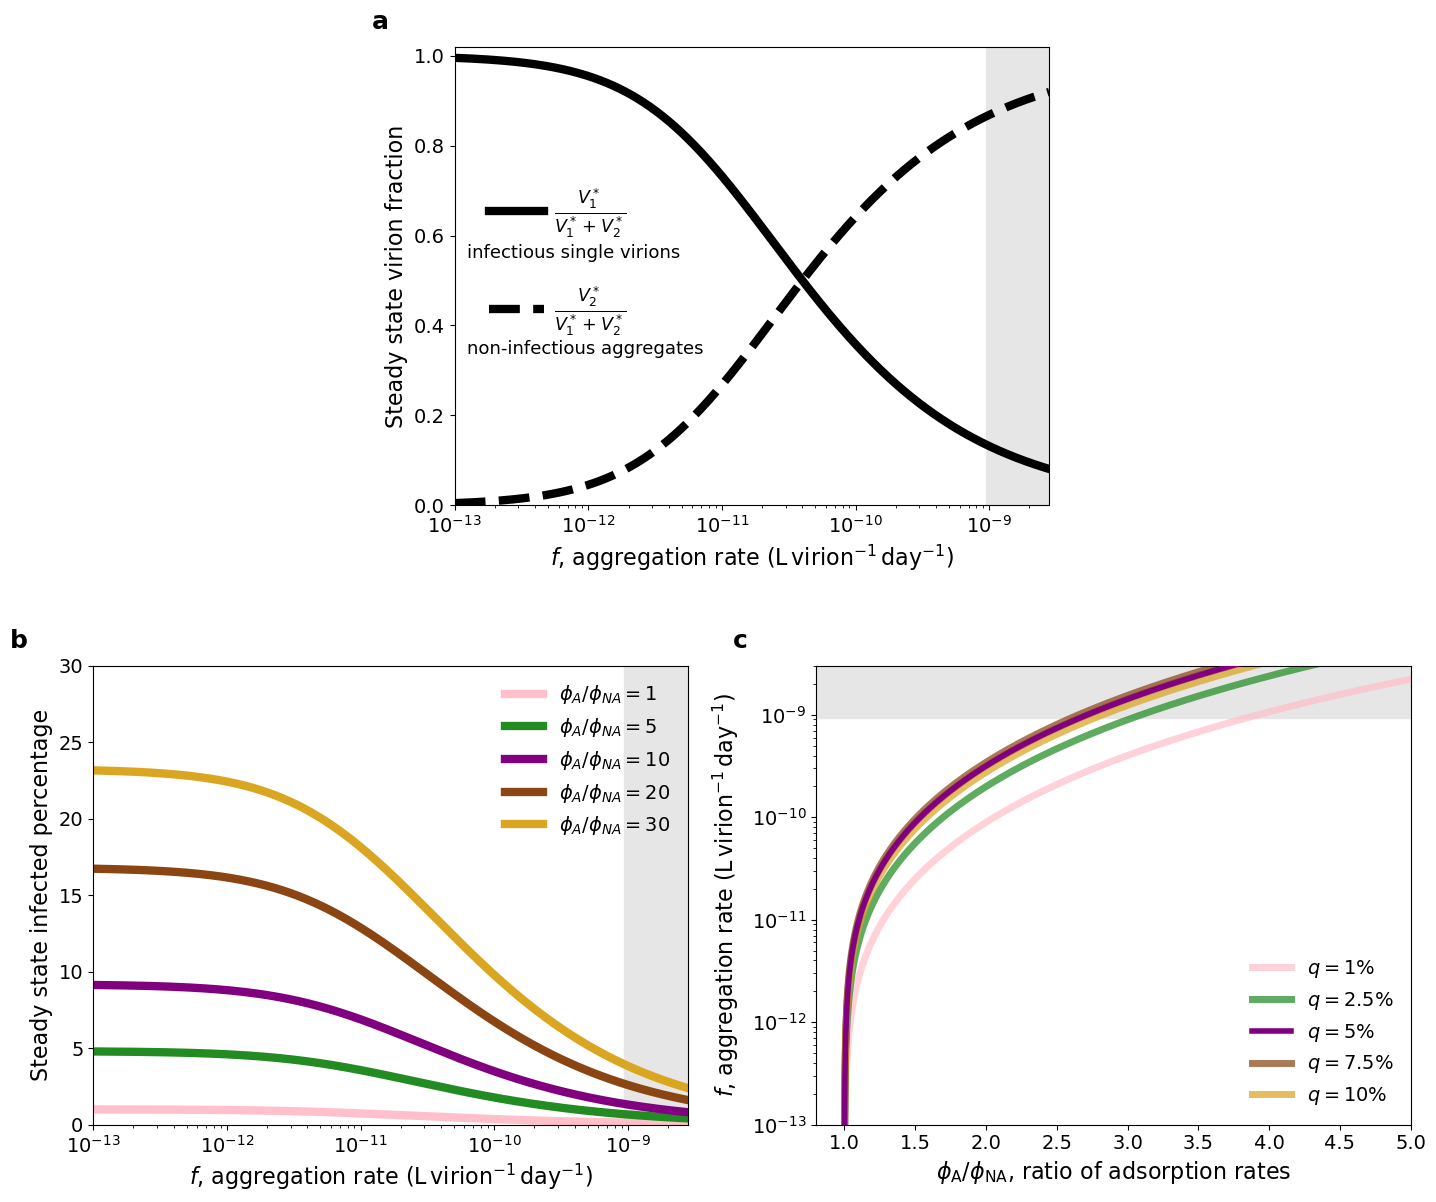

In [11]:




fig = plt.figure(figsize=(17, 14))
gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 1.0], hspace=0.35, wspace=0.55)

ax1 = fig.add_subplot(gs[0, 1:3])
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])



panel_colors = ["pink", "forestgreen", "purple", "saddlebrown", "goldenrod"]
gray_region_color = "0.90"


# Panel a: z(f) and y(f)


ax1.axvspan(f_limit, f_plot_max, color=gray_region_color, zorder=0)

line1, = ax1.plot(f_values, z(f_values), linewidth=6, color="black", linestyle="-", label=r"$\frac{V_1^*}{V_1^*+V_2^*}$")
line2, = ax1.plot(f_values, y(f_values), linewidth=6, color="black", linestyle="--", label=r"$\frac{V_2^*}{V_1^*+V_2^*}$")

ax1.set_xlabel(r"$f$, aggregation rate ($\mathrm{L\,virion^{-1}\,day^{-1}}$)", fontsize=16)
ax1.set_ylabel("Steady state virion fraction", fontsize=16)
ax1.set_xscale("log")
ax1.set_xlim(f_min, f_plot_max)
ax1.set_ylim(0, 1.02)
ax1.tick_params(axis="both", which="both", labelsize=14)

leg = ax1.legend(loc="center left", bbox_to_anchor=(0.02, 0.53), handlelength=2.2, handletextpad=0.4, frameon=False, fontsize=18, labelspacing=1.8)

# Separate descriptive text under each fraction
ax1.text(0.02, 0.55, "infectious single virions", transform=ax1.transAxes, fontsize=13, ha="left", va="center")
ax1.text(0.02, 0.34, "non-infectious aggregates", transform=ax1.transAxes, fontsize=13, ha="left", va="center")

ax1.text(-0.14, 1.08, "a", transform=ax1.transAxes, ha="left", va="top", fontsize=18, fontweight="bold")

# Panel b: 100 q(f, phi_A/phi_NA)


ax2.axvspan(f_limit, f_plot_max, color=gray_region_color, zorder=0)

for x, color in zip(phi_ratios, panel_colors):
    ax2.plot(f_values, 100.0*q_infected(f_values, x), linewidth=6, color=color, label=rf"$\phi_A/\phi_{{NA}}={x:g}$")

ax2.set_xlabel(r"$f$, aggregation rate ($\mathrm{L\,virion^{-1}\,day^{-1}}$)", fontsize=16)
ax2.set_ylabel("Steady state infected percentage", fontsize=16)
ax2.set_xscale("log")
ax2.set_xlim(f_min, f_plot_max)
ax2.set_ylim(0, 30)
ax2.tick_params(axis="both", which="both", labelsize=14)
ax2.legend(frameon=False, fontsize=14, loc="upper right")

ax2.text(-0.14, 1.08, "b", transform=ax2.transAxes, ha="left", va="top", fontsize=18, fontweight="bold")


# Panel c: f(phi_A/phi_NA)


ax3.axhspan(f_limit, panel_c_ymax, color=gray_region_color, zorder=0)

# Plot all except q = 5% first
for q, color in zip(q_values, panel_colors):

    f_curve = f_nonidentifiability(x_values, q)
  
    ax3.plot(x_values, f_curve, linewidth=5, color=color, alpha=0.72, label=rf"$q={100*q:g}\%$", zorder=2)

# Plot q = 5% last so it remains visible
q = 0.05
color = panel_colors[2]
f_curve = f_nonidentifiability(x_values, q)

ax3.plot(x_values, f_curve, linewidth=4, color=color, label=r"$q=5\%$", zorder=10)

ax3.set_xlabel(r"$\phi_{\mathrm{A}}/\phi_{\mathrm{NA}}$, ratio of adsorption rates", fontsize=16)
ax3.set_ylabel(r"$f$, aggregation rate ($\mathrm{L\,virion^{-1}\,day^{-1}}$)", fontsize=16, labelpad=8)
ax3.set_yscale("log")
ax3.set_xlim(0.8, 5.0)
ax3.set_ylim(f_min, panel_c_ymax)
ax3.tick_params(axis="both", which="both", labelsize=14)

handles, labels = ax3.get_legend_handles_labels()
desired_labels = [r"$q=1\%$", r"$q=2.5\%$", r"$q=5\%$", r"$q=7.5\%$", r"$q=10\%$"]
handle_dict = dict(zip(labels, handles))

ax3.legend([handle_dict[label] for label in desired_labels], desired_labels, frameon=False, fontsize=14, loc="lower right")

ax3.text(-0.14, 1.08, "c", transform=ax3.transAxes, ha="left", va="top", fontsize=18, fontweight="bold")
plt.savefig("combined_SS.pdf", bbox_inches="tight")
plt.show()